### Description: 

### This script filters daily and by hydrobasin grouped water quality data, keeping only rows which comprises all fractions of interest.

In [25]:
import pandas as pd
import numpy as np
from time import time 
from tqdm import tqdm
import pickle
import geopandas as gpd
import os

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import geodatasets

In [4]:
# define the output folder path:

output_folder = '../../output_data/CNP_data_catchments'

# Check if the folder exists, if not, create it:
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [5]:
tic = time()
wq_data = pickle.load(open('../../output_data/aggregate_stations_by_subbasins/daily_wq_data_by_subbasin_0km_merged.pkl','rb'))
print("Elapsed %.2f seconds" % ((time() - tic)))

Elapsed 12.07 seconds


## Filter rows where fractions of interst are available in combination: 

### 1. DOC_DIN_TP: DOC or TOC and for DIN NO3N, NH4N, optional also NO2N and for  P TP
### 2. DOC-DIN-SRP: DOC or TOC and for  DIN NO3N, NH4N, optional also NO2N and for  SRP OPO4 or DIP:

### Function for filtering: required arguments are:

### data: water quality data 
### combination of fractions: DOC_TOC_DIN_TP or DOC_TOC_DIN_SRP
### metric: metric of interest: mean or median

In [6]:
# This function filter_combinations() filters daily water quality data (which are already assigned to Hydrobasins ) 
# result contains only obs_dates and Hydrobasins that have all required compounds available 
# additional the functions calculates DIN, DOC_TOC or SRP depending on chosen combination and standard deviations


# required arguments are: data (water quality data) , combi (combination of fractions either 'DOC_TOC_DIN_TP' or 'DOC_TOC_DIN_SRP') and metric (mean, max, sd, etc. depending on available columns in data)
#data = wq_data
#combi = 'DOC_TOC_DIN_TP'
#metric = 'mean'
def filter_combinations(data, combi, metric):

    if combi == 'DOC_TOC_DIN_TP':
            DOC_TOC_DIN_TP_daily = data[(data[f'NO3N_{metric}'].notna()|data[f'NO2N_NO3N_{metric}'].notna())& (data[f'NH4N_{metric}'].notna())&(data[f'DOC_{metric}'].notna()|data[f'TOC_{metric}'].notna())& (data[f'TP_{metric}'].notna())]
            DOC_TOC_DIN_TP_daily.loc[:,f'DOC_TOC_{metric}'] = np.where(DOC_TOC_DIN_TP_daily.loc[:,f'DOC_{metric}'].notna(), DOC_TOC_DIN_TP_daily.loc[:,f'DOC_{metric}'], DOC_TOC_DIN_TP_daily.loc[:,f'TOC_{metric}'])
            DOC_TOC_DIN_TP_daily.loc[:,'DOC_TOC_logmean'] = np.where(DOC_TOC_DIN_TP_daily.loc[:,'DOC_logmean'].notna(), DOC_TOC_DIN_TP_daily.loc[:,'DOC_logmean'], DOC_TOC_DIN_TP_daily.loc[:,'TOC_logmean'])
            # replace sd values by zero if only one value available:
            DOC_TOC_DIN_TP_daily.loc[DOC_TOC_DIN_TP_daily['DOC_n'] == 1, 'DOC_sd'] = 0 
            DOC_TOC_DIN_TP_daily.loc[DOC_TOC_DIN_TP_daily['TOC_n'] == 1, 'TOC_sd'] = 0 
            DOC_TOC_DIN_TP_daily.loc[DOC_TOC_DIN_TP_daily['TP_n'] == 1, 'TP_sd'] = 0 
            DOC_TOC_DIN_TP_daily.loc[DOC_TOC_DIN_TP_daily['DOC_n'] == 1, 'DOC_logsd'] = 0 
            DOC_TOC_DIN_TP_daily.loc[DOC_TOC_DIN_TP_daily['TOC_n'] == 1, 'TOC_logsd'] = 0 
            DOC_TOC_DIN_TP_daily.loc[DOC_TOC_DIN_TP_daily['TP_n'] == 1, 'TP_logsd'] = 0 
            # add column sd_DOC_TOC:
            DOC_TOC_DIN_TP_daily.loc[:,'DOC_TOC_sd'] = np.where(DOC_TOC_DIN_TP_daily.loc[:,f'DOC_{metric}'].notna(), DOC_TOC_DIN_TP_daily.loc[:,'DOC_sd'], DOC_TOC_DIN_TP_daily.loc[:,'TOC_sd'])
            DOC_TOC_DIN_TP_daily.loc[:,'DOC_TOC_logsd'] = np.where(DOC_TOC_DIN_TP_daily.loc[:,f'DOC_{metric}'].notna(), DOC_TOC_DIN_TP_daily.loc[:,'DOC_logsd'], DOC_TOC_DIN_TP_daily.loc[:,'TOC_logsd'])
            DOC_TOC_DIN_TP_daily.loc[:,f'DIN_{metric}'] = np.where(DOC_TOC_DIN_TP_daily[f'NO3N_{metric}'].notna(), DOC_TOC_DIN_TP_daily[[f'NO3N_{metric}', f'NH4N_{metric}', f'NO2N_{metric}']].sum(axis = 1), DOC_TOC_DIN_TP_daily[[f'NO2N_NO3N_{metric}', f'NH4N_{metric}']].sum(axis = 1))
            DOC_TOC_DIN_TP_daily.loc[:,'DIN_logmean'] = np.where(DOC_TOC_DIN_TP_daily['NO3N_logmean'].notna(), DOC_TOC_DIN_TP_daily[['NO3N_logmean', 'NH4N_logmean', 'NO2N_logmean']].sum(axis = 1), DOC_TOC_DIN_TP_daily[['NO2N_NO3N_logmean', 'NH4N_logmean']].sum(axis = 1))
            # calculation of sd of DIN:
            # if only one value for NO3N, NH4N, NO2N or NO2N_NO3N is available sd is set to zero:
            mask = DOC_TOC_DIN_TP_daily[f'NO3N_{metric}'].notna()
            DOC_TOC_DIN_TP_daily.loc[mask, ['NO3N_sd', 'NH4N_sd', 'NO2N_sd']] = DOC_TOC_DIN_TP_daily.loc[mask, ['NO3N_sd', 'NH4N_sd', 'NO2N_sd']].fillna(0)
            DOC_TOC_DIN_TP_daily.loc[mask, ['NO3N_logsd', 'NH4N_logsd', 'NO2N_logsd']] = DOC_TOC_DIN_TP_daily.loc[mask, ['NO3N_logsd', 'NH4N_logsd', 'NO2N_logsd']].fillna(0)
            # and if NO2N_NO3N available:
            mask2 = DOC_TOC_DIN_TP_daily[f'NO2N_NO3N_{metric}'].notna()
            DOC_TOC_DIN_TP_daily.loc[mask2, ['NO2N_NO3N_sd', 'NH4N_sd']] = DOC_TOC_DIN_TP_daily.loc[mask2, ['NO2N_NO3N_sd', 'NH4N_sd']].fillna(0)
            DOC_TOC_DIN_TP_daily.loc[mask2, ['NO2N_NO3N_logsd', 'NH4N_logsd']] = DOC_TOC_DIN_TP_daily.loc[mask2, ['NO2N_NO3N_logsd', 'NH4N_logsd']].fillna(0)
            # add column DIN_sd calculated from sum of variances
            DOC_TOC_DIN_TP_daily.loc[:,'DIN_sd'] = np.where(DOC_TOC_DIN_TP_daily[f'NO3N_{metric}'].notna(), (DOC_TOC_DIN_TP_daily['NO3N_sd']**2 +DOC_TOC_DIN_TP_daily['NH4N_sd']**2 + DOC_TOC_DIN_TP_daily['NO2N_sd'])**0.5, (DOC_TOC_DIN_TP_daily['NO2N_NO3N_sd']**2 + DOC_TOC_DIN_TP_daily['NH4N_sd'])**0.5)
            DOC_TOC_DIN_TP_daily.loc[:,'DIN_logsd'] = np.where(DOC_TOC_DIN_TP_daily[f'NO3N_{metric}'].notna(), (DOC_TOC_DIN_TP_daily['NO3N_logsd']**2 +DOC_TOC_DIN_TP_daily['NH4N_logsd']**2 + DOC_TOC_DIN_TP_daily['NO2N_logsd'])**0.5, (DOC_TOC_DIN_TP_daily['NO2N_NO3N_logsd']**2 + DOC_TOC_DIN_TP_daily['NH4N_logsd'])**0.5)
            # convert units from mg/L to g/L
            DOC_TOC_DIN_TP_daily['DIN_gL'] = DOC_TOC_DIN_TP_daily[f'DIN_{metric}']/1000
            DOC_TOC_DIN_TP_daily.loc[:,'DIN_sd_gL'] = DOC_TOC_DIN_TP_daily.loc[:,'DIN_sd']/1000
            DOC_TOC_DIN_TP_daily.loc[:,'DIN_sd_gL'] = DOC_TOC_DIN_TP_daily.loc[:,'DIN_sd']/1000
            DOC_TOC_DIN_TP_daily['DOC_TOC_gL'] = DOC_TOC_DIN_TP_daily[f'DOC_TOC_{metric}']/1000
            DOC_TOC_DIN_TP_daily.loc[:,'DOC_TOC_sd_gL'] = DOC_TOC_DIN_TP_daily.loc[:,'DOC_TOC_sd']/1000
            #DOC_TOC_DIN_TP_daily.loc[:,'DOC_TOC_sd_gL_bioav'] = DOC_TOC_DIN_TP_daily.loc[:,'DOC_TOC_sd_gL']*0.16
            #DOC_TOC_DIN_TP_daily['DOC_TOC_gL_bioav'] = DOC_TOC_DIN_TP_daily['DOC_TOC_gL'] * 0.16
            DOC_TOC_DIN_TP_daily['TP_gL'] = DOC_TOC_DIN_TP_daily[f'TP_{metric}']/1000
            DOC_TOC_DIN_TP_daily['TP_sd_gL'] = DOC_TOC_DIN_TP_daily['TP_sd']/1000 


            DOC_TOC_DIN_TP_daily['NH4N_gL'] = DOC_TOC_DIN_TP_daily[f'NH4N_{metric}']/1000
            DOC_TOC_DIN_TP_daily['NH4N_sd_gL'] = DOC_TOC_DIN_TP_daily['NH4N_sd']/1000
            DOC_TOC_DIN_TP_daily['NO3N_gL'] = DOC_TOC_DIN_TP_daily[f'NO3N_{metric}']/1000
            DOC_TOC_DIN_TP_daily['NO3N_sd_gL'] = DOC_TOC_DIN_TP_daily['NO3N_sd']/1000
            DOC_TOC_DIN_TP_daily['NO2N_gL'] = DOC_TOC_DIN_TP_daily[f'NO2N_{metric}']/1000
            DOC_TOC_DIN_TP_daily['NO2N_sd_gL'] = DOC_TOC_DIN_TP_daily['NO2N_sd']/1000
            DOC_TOC_DIN_TP_daily['NO2N_NO3N_gL'] = DOC_TOC_DIN_TP_daily[f'NO2N_NO3N_{metric}']/1000
            DOC_TOC_DIN_TP_daily['NO2N_NO3N_sd_gL'] = DOC_TOC_DIN_TP_daily['NO2N_NO3N_sd']/1000
            #drop not required columns:
            DOC_TOC_DIN_TP_daily = DOC_TOC_DIN_TP_daily.drop(DOC_TOC_DIN_TP_daily.filter(regex='OPO4').columns, axis=1)
            DOC_TOC_DIN_TP_daily = DOC_TOC_DIN_TP_daily.drop(DOC_TOC_DIN_TP_daily.filter(regex='DIP').columns, axis=1)
            # return datframe:
            print('Output dataframe: DOC_TOC_DIN_TP_daily generated')
            return DOC_TOC_DIN_TP_daily
            
                                                   
    elif combi == 'DOC_TOC_DIN_SRP':
        DOC_TOC_DIN_SRP_daily = data[(data[f'NO3N_{metric}'].notna()|data[f'NO2N_NO3N_{metric}'].notna())& (data[f'NH4N_{metric}'].notna())&(data[f'DOC_{metric}'].notna()|data[f'TOC_{metric}'].notna())& ((data[f'OPO4_{metric}'].notna())|(data[f'DIP_{metric}'].notna()))]
        DOC_TOC_DIN_SRP_daily.loc[:,f'DOC_TOC_{metric}'] = np.where(DOC_TOC_DIN_SRP_daily.loc[:,f'DOC_{metric}'].notna(), DOC_TOC_DIN_SRP_daily.loc[:,f'DOC_{metric}'], DOC_TOC_DIN_SRP_daily.loc[:,f'TOC_{metric}'])
        DOC_TOC_DIN_SRP_daily.loc[:,'DOC_TOC_logmean'] = np.where(DOC_TOC_DIN_SRP_daily.loc[:,'DOC_logmean'].notna(), DOC_TOC_DIN_SRP_daily.loc[:,'DOC_logmean'], DOC_TOC_DIN_SRP_daily.loc[:,'TOC_logmean'])
        # replace sd values by zero if only one value available:
        DOC_TOC_DIN_SRP_daily.loc[DOC_TOC_DIN_SRP_daily['DOC_n'] == 1, 'DOC_sd'] = 0 
        DOC_TOC_DIN_SRP_daily.loc[DOC_TOC_DIN_SRP_daily['TOC_n'] == 1, 'TOC_sd'] = 0
        DOC_TOC_DIN_SRP_daily.loc[DOC_TOC_DIN_SRP_daily['OPO4_n'] == 1, 'OPO4_sd'] = 0
        DOC_TOC_DIN_SRP_daily.loc[DOC_TOC_DIN_SRP_daily['DIP_n'] == 1, 'DIP_sd'] = 0
        DOC_TOC_DIN_SRP_daily.loc[DOC_TOC_DIN_SRP_daily['DOC_n'] == 1, 'DOC_logsd'] = 0 
        DOC_TOC_DIN_SRP_daily.loc[DOC_TOC_DIN_SRP_daily['TOC_n'] == 1, 'TOC_logsd'] = 0
        DOC_TOC_DIN_SRP_daily.loc[DOC_TOC_DIN_SRP_daily['OPO4_n'] == 1, 'OPO4_logsd'] = 0
        DOC_TOC_DIN_SRP_daily.loc[DOC_TOC_DIN_SRP_daily['DIP_n'] == 1, 'DIP_logsd'] = 0
        # add column sd_DOC_TOC:
        DOC_TOC_DIN_SRP_daily.loc[:,'DOC_TOC_sd'] = np.where(DOC_TOC_DIN_SRP_daily.loc[:,f'DOC_{metric}'].notna(), DOC_TOC_DIN_SRP_daily.loc[:,'DOC_sd'], DOC_TOC_DIN_SRP_daily.loc[:,'TOC_sd'])
        DOC_TOC_DIN_SRP_daily.loc[:,'DOC_TOC_logsd'] = np.where(DOC_TOC_DIN_SRP_daily.loc[:,f'DOC_{metric}'].notna(), DOC_TOC_DIN_SRP_daily.loc[:,'DOC_logsd'], DOC_TOC_DIN_SRP_daily.loc[:,'TOC_logsd'])
        DOC_TOC_DIN_SRP_daily.loc[:,f'DIN_{metric}'] = np.where(DOC_TOC_DIN_SRP_daily[f'NO3N_{metric}'].notna(), DOC_TOC_DIN_SRP_daily[[f'NO3N_{metric}', f'NH4N_{metric}', f'NO2N_{metric}']].sum(axis = 1),DOC_TOC_DIN_SRP_daily[[f'NO2N_NO3N_{metric}', f'NH4N_{metric}']].sum(axis = 1))
        DOC_TOC_DIN_SRP_daily.loc[:,'DIN_logmean'] = np.where(DOC_TOC_DIN_SRP_daily['NO3N_logmean'].notna(), DOC_TOC_DIN_SRP_daily[['NO3N_logmean', 'NH4N_logmean', 'NO2N_logmean']].sum(axis = 1),DOC_TOC_DIN_SRP_daily[['NO2N_NO3N_logmean', 'NH4N_logmean']].sum(axis = 1))
        # calculation of sd of DIN:
        # if only one value for NO3N, NH4N, NO2N or NO2N_NO3N is available sd is set to zero:
        mask = DOC_TOC_DIN_SRP_daily[f'NO3N_{metric}'].notna()
        DOC_TOC_DIN_SRP_daily.loc[mask, ['NO3N_sd', 'NH4N_sd', 'NO2N_sd']] = DOC_TOC_DIN_SRP_daily.loc[mask, ['NO3N_sd', 'NH4N_sd', 'NO2N_sd']].fillna(0)
        DOC_TOC_DIN_SRP_daily.loc[mask, ['NO3N_logsd', 'NH4N_logsd', 'NO2N_logsd']] = DOC_TOC_DIN_SRP_daily.loc[mask, ['NO3N_logsd', 'NH4N_logsd', 'NO2N_logsd']].fillna(0)
        # and if NO2N_NO3N available:
        mask2 = DOC_TOC_DIN_SRP_daily[f'NO2N_NO3N_{metric}'].notna()
        DOC_TOC_DIN_SRP_daily.loc[mask2, ['NO2N_NO3N_sd', 'NH4N_sd']] = DOC_TOC_DIN_SRP_daily.loc[mask2, ['NO2N_NO3N_sd', 'NH4N_sd']].fillna(0)
        DOC_TOC_DIN_SRP_daily.loc[mask2, ['NO2N_NO3N_logsd', 'NH4N_logsd']] = DOC_TOC_DIN_SRP_daily.loc[mask2, ['NO2N_NO3N_logsd', 'NH4N_logsd']].fillna(0) 
        # add column DIN_sd calculated from sum of variances
        DOC_TOC_DIN_SRP_daily.loc[:,'DIN_sd'] = np.where(DOC_TOC_DIN_SRP_daily[f'NO3N_{metric}'].notna(), (DOC_TOC_DIN_SRP_daily['NO3N_sd']**2 +DOC_TOC_DIN_SRP_daily['NH4N_sd']**2 + DOC_TOC_DIN_SRP_daily['NO2N_sd'])**0.5, (DOC_TOC_DIN_SRP_daily['NO2N_NO3N_sd']**2 + DOC_TOC_DIN_SRP_daily['NH4N_sd'])**0.5)
        DOC_TOC_DIN_SRP_daily.loc[:,'DIN_logsd'] = np.where(DOC_TOC_DIN_SRP_daily[f'NO3N_{metric}'].notna(), (DOC_TOC_DIN_SRP_daily['NO3N_logsd']**2 +DOC_TOC_DIN_SRP_daily['NH4N_logsd']**2 + DOC_TOC_DIN_SRP_daily['NO2N_logsd'])**0.5, (DOC_TOC_DIN_SRP_daily['NO2N_NO3N_logsd']**2 + DOC_TOC_DIN_SRP_daily['NH4N_logsd'])**0.5)
        DOC_TOC_DIN_SRP_daily.loc[:,f'SRP_{metric}'] = np.where(DOC_TOC_DIN_SRP_daily.loc[:,f'DIP_{metric}'].notna(), DOC_TOC_DIN_SRP_daily.loc[:,f'DIP_{metric}'], DOC_TOC_DIN_SRP_daily.loc[:,f'OPO4_{metric}'])
        DOC_TOC_DIN_SRP_daily.loc[:,'SRP_logmean'] = np.where(DOC_TOC_DIN_SRP_daily.loc[:,'DIP_logmean'].notna(), DOC_TOC_DIN_SRP_daily.loc[:,'DIP_logmean'], DOC_TOC_DIN_SRP_daily.loc[:,'OPO4_logmean'])
        # add column sd_SRP:
        DOC_TOC_DIN_SRP_daily.loc[:,'SRP_sd'] = np.where(DOC_TOC_DIN_SRP_daily.loc[:,f'DIP_{metric}'].notna(), DOC_TOC_DIN_SRP_daily.loc[:,'DIP_sd'], DOC_TOC_DIN_SRP_daily.loc[:,'OPO4_sd'])
        DOC_TOC_DIN_SRP_daily.loc[:,'SRP_logsd'] = np.where(DOC_TOC_DIN_SRP_daily.loc[:,f'DIP_{metric}'].notna(), DOC_TOC_DIN_SRP_daily.loc[:,'DIP_logsd'], DOC_TOC_DIN_SRP_daily.loc[:,'OPO4_logsd'])
        # convert units from mg/L to g/L
        #DIN
        DOC_TOC_DIN_SRP_daily['DIN_gL'] = DOC_TOC_DIN_SRP_daily[f'DIN_{metric}']/1000
        DOC_TOC_DIN_SRP_daily.loc[:,'DIN_sd_gL'] = DOC_TOC_DIN_SRP_daily.loc[:,'DIN_sd']/1000
        # DOC additional calc bioavailable fraction:
        DOC_TOC_DIN_SRP_daily['DOC_TOC_gL'] = DOC_TOC_DIN_SRP_daily[f'DOC_TOC_{metric}']/1000
        #DOC_TOC_DIN_SRP_daily['DOC_TOC_gL_bioav'] = DOC_TOC_DIN_SRP_daily['DOC_TOC_gL'] * 0.16
        DOC_TOC_DIN_SRP_daily.loc[:,'DOC_TOC_sd_gL'] = DOC_TOC_DIN_SRP_daily.loc[:,'DOC_TOC_sd']/1000
        #DOC_TOC_DIN_SRP_daily.loc[:,'DOC_TOC_sd_gL_bioav'] = DOC_TOC_DIN_SRP_daily.loc[:,'DOC_TOC_sd_gL']*0.16
        DOC_TOC_DIN_SRP_daily['SRP_gL'] = DOC_TOC_DIN_SRP_daily[f'SRP_{metric}']/1000
        DOC_TOC_DIN_SRP_daily.loc[:,'SRP_sd_gL'] = DOC_TOC_DIN_SRP_daily.loc[:,'SRP_sd']/1000

        DOC_TOC_DIN_SRP_daily['NH4N_gL'] = DOC_TOC_DIN_SRP_daily[f'NH4N_{metric}']/1000
        DOC_TOC_DIN_SRP_daily['NH4N_sd_gL'] = DOC_TOC_DIN_SRP_daily['NH4N_sd']/1000
        DOC_TOC_DIN_SRP_daily['NO3N_gL'] = DOC_TOC_DIN_SRP_daily[f'NO3N_{metric}']/1000
        DOC_TOC_DIN_SRP_daily['NO3N_sd_gL'] = DOC_TOC_DIN_SRP_daily['NO3N_sd']/1000
        DOC_TOC_DIN_SRP_daily['NO2N_gL'] = DOC_TOC_DIN_SRP_daily[f'NO2N_{metric}']/1000
        DOC_TOC_DIN_SRP_daily['NO2N_sd_gL'] = DOC_TOC_DIN_SRP_daily['NO2N_sd']/1000
        DOC_TOC_DIN_SRP_daily['NO2N_NO3N_gL'] = DOC_TOC_DIN_SRP_daily[f'NO2N_NO3N_{metric}']/1000
        DOC_TOC_DIN_SRP_daily['NO2N_NO3N_sd_gL'] = DOC_TOC_DIN_SRP_daily['NO2N_NO3N_sd']/1000
        
        
        #drop not required columns:
        DOC_TOC_DIN_SRP_daily = DOC_TOC_DIN_SRP_daily.drop(DOC_TOC_DIN_SRP_daily.filter(regex='TP').columns, axis=1)
    
        # return datframe: 
        print('Output dataframe: DOC_TOC_DIN_SRP_daily generated')
        return DOC_TOC_DIN_SRP_daily
        
    
    
    else: 
        print('Define correct combination of fractions! You can choose: "DOC_TOC_DIN_TP" or "DOC_TOC_DIN_SRP".')
                            

In [7]:
## filter water quality data for available combinations of DOC_TOC:DIN:TP applying function filter_combinations
## additional corresponding standard deviations are computed
## metric = mean --> we are looking at mean values since we assume that data are normal distributed



In [8]:
DOC_TOC_DIN_TP_daily = filter_combinations(data = wq_data, combi = 'DOC_TOC_DIN_TP', metric = 'median')

C:\Users\alexd\AppData\Local\Temp\ipykernel_43448\4292709918.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DOC_TOC_DIN_TP_daily.loc[:,f'DOC_TOC_{metric}'] = np.where(DOC_TOC_DIN_TP_daily.loc[:,f'DOC_{metric}'].notna(), DOC_TOC_DIN_TP_daily.loc[:,f'DOC_{metric}'], DOC_TOC_DIN_TP_daily.loc[:,f'TOC_{metric}'])
C:\Users\alexd\AppData\Local\Temp\ipykernel_43448\4292709918.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DOC_TOC_DIN_TP_daily.loc[:,'DOC_TOC_logmean'] = np.where(DOC_TOC_DIN_TP_daily.loc[

Output dataframe: DOC_TOC_DIN_TP_daily generated


In [9]:
DOC_TOC_DIN_SRP_daily = filter_combinations(data = wq_data, combi = 'DOC_TOC_DIN_SRP', metric = 'median')

C:\Users\alexd\AppData\Local\Temp\ipykernel_43448\4292709918.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DOC_TOC_DIN_SRP_daily.loc[:,f'DOC_TOC_{metric}'] = np.where(DOC_TOC_DIN_SRP_daily.loc[:,f'DOC_{metric}'].notna(), DOC_TOC_DIN_SRP_daily.loc[:,f'DOC_{metric}'], DOC_TOC_DIN_SRP_daily.loc[:,f'TOC_{metric}'])
C:\Users\alexd\AppData\Local\Temp\ipykernel_43448\4292709918.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DOC_TOC_DIN_SRP_daily.loc[:,'DOC_TOC_logmean'] = np.where(DOC_TOC_DIN_SRP_dail

Output dataframe: DOC_TOC_DIN_SRP_daily generated


In [10]:
DOC_TOC_DIN_SRP_daily

,HYBAS_ID,obs_date,NO3N_median,NO3N_25,NO3N_75,NO3N_mean,NO3N_sd,NO3N_min,NO3N_max,NO3N_n,...,SRP_gL,SRP_sd_gL,NH4N_gL,NH4N_sd_gL,NO3N_gL,NO3N_sd_gL,NO2N_gL,NO2N_sd_gL,NO2N_NO3N_gL,NO2N_NO3N_sd_gL
11041,1121145450,2008-02-18,0.252966,0.252966,0.252966,0.252966,0.000000,0.252966,0.252966,1.0,...,0.000033,0.000000,7.003500e-07,0.000000,0.000253,0.000000,NaN,0.000000e+00,NaN,NaN
11042,1121146530,2008-02-17,1.348874,1.279960,1.417789,1.348874,0.194919,1.211045,1.486703,2.0,...,0.000132,0.000015,9.524760e-06,0.000006,0.001349,0.000195,NaN,0.000000e+00,NaN,NaN
11062,1121150540,2008-02-19,0.214727,0.214727,0.214727,0.214727,0.000000,0.214727,0.214727,1.0,...,0.000010,0.000000,4.902450e-06,0.000000,0.000215,0.000000,NaN,0.000000e+00,NaN,NaN
11066,1121151290,2008-02-19,0.097909,0.097909,0.097909,0.097909,0.000000,0.097909,0.097909,1.0,...,0.000113,0.000000,8.824410e-06,0.000000,0.000098,0.000000,NaN,0.000000e+00,NaN,NaN
11067,1121151840,2008-02-21,0.238119,0.238119,0.238119,0.238119,0.000000,0.238119,0.238119,1.0,...,0.000072,0.000000,9.664830e-06,0.000000,0.000238,0.000000,NaN,0.000000e+00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2505850,8120280400,2001-07-24,0.156000,0.156000,0.156000,0.156000,0.000000,0.156000,0.156000,1.0,...,0.000003,0.000000,2.997498e-06,0.000000,0.000156,0.000000,9.972485e-07,3.891209e-09,NaN,NaN
2505851,8120280400,2001-08-08,0.129000,0.129000,0.129000,0.129000,0.000000,0.129000,0.129000,1.0,...,0.000003,0.000000,2.997498e-06,0.000000,0.000129,0.000000,9.972485e-07,3.891209e-09,NaN,NaN
2505852,8120280400,2001-09-05,0.141000,0.141000,0.141000,0.141000,0.000000,0.141000,0.141000,1.0,...,0.000003,0.000000,9.944970e-07,0.000000,0.000141,0.000000,9.972485e-07,3.891209e-09,NaN,NaN
2507528,8120295370,2001-04-24,0.085000,0.085000,0.085000,0.085000,0.000000,0.085000,0.085000,1.0,...,0.000016,0.000000,5.000499e-06,0.000000,0.000085,0.000000,9.972485e-07,3.891209e-09,NaN,NaN


## Add latitude and longitude coordinates of centroids of HydroBasins to dataframes: 

In [11]:
gdf = gpd.GeoDataFrame(DOC_TOC_DIN_TP_daily,crs="EPSG:4326")
#gdf['centroid_lon'] = gdf['geometry'].centroid.x
#gdf['centroid_lat'] = gdf['geometry'].centroid.y

# probably +proj=cea is the best way: +proj=cea suitable to calculate distances, subsequently convert back to EPSG:4326:
centroids = gdf.to_crs('+proj=cea').centroid.to_crs(epsg=4326)

# add columns to DOC_TOC_DIN_TP_daily dataframe:
DOC_TOC_DIN_TP_daily['centroid_lon'] = centroids.x
DOC_TOC_DIN_TP_daily['centroid_lat'] = centroids.y


In [12]:
gdf_srp = gpd.GeoDataFrame(DOC_TOC_DIN_SRP_daily, crs = "EPSG:4326")
# probably +proj=cea is the best way: +proj=cea suitable to calculate distances, subseqquently convert back to EPSG:4326:
centroids = gdf_srp.to_crs('+proj=cea').centroid.to_crs(epsg=4326)

# add columns to DOC_TOC_DIN_SRP_daily dataframe:
DOC_TOC_DIN_SRP_daily['centroid_lon'] = centroids.x
DOC_TOC_DIN_SRP_daily['centroid_lat'] = centroids.y



In [13]:
DOC_TOC_DIN_TP_daily.head(10)


,HYBAS_ID,obs_date,NO3N_median,NO3N_25,NO3N_75,NO3N_mean,NO3N_sd,NO3N_min,NO3N_max,NO3N_n,...,NH4N_gL,NH4N_sd_gL,NO3N_gL,NO3N_sd_gL,NO2N_gL,NO2N_sd_gL,NO2N_NO3N_gL,NO2N_NO3N_sd_gL,centroid_lon,centroid_lat
293410,2120012180,2013-01-21,0.545022,0.545022,0.545022,0.545022,0.0,0.545022,0.545022,1.0,...,0.000010,0.0,0.000545,0.0,0.000003,0.0,NaN,NaN,17.600678,43.040486
293411,2120012180,2013-04-02,0.342014,0.342014,0.342014,0.342014,0.0,0.342014,0.342014,1.0,...,0.000010,0.0,0.000342,0.0,0.000004,0.0,NaN,NaN,17.600678,43.040486
293412,2120012180,2013-06-13,0.352014,0.352014,0.352014,0.352014,0.0,0.352014,0.352014,1.0,...,0.000012,0.0,0.000352,0.0,0.000002,0.0,NaN,NaN,17.600678,43.040486
293413,2120012180,2013-08-28,0.536022,0.536022,0.536022,0.536022,0.0,0.536022,0.536022,1.0,...,0.000011,0.0,0.000536,0.0,0.000004,0.0,NaN,NaN,17.600678,43.040486
293414,2120012180,2013-10-14,0.557023,0.557023,0.557023,0.557023,0.0,0.557023,0.557023,1.0,...,0.000010,0.0,0.000557,0.0,0.000003,0.0,NaN,NaN,17.600678,43.040486
293415,2120012180,2013-12-11,0.545022,0.545022,0.545022,0.545022,0.0,0.545022,0.545022,1.0,...,0.000010,0.0,0.000545,0.0,0.000002,0.0,NaN,NaN,17.600678,43.040486
293416,2120012180,2014-02-12,0.406016,0.406016,0.406016,0.406016,0.0,0.406016,0.406016,1.0,...,0.000010,0.0,0.000406,0.0,0.000003,0.0,NaN,NaN,17.600678,43.040486
293417,2120012180,2014-04-09,0.379015,0.379015,0.379015,0.379015,0.0,0.379015,0.379015,1.0,...,0.000010,0.0,0.000379,0.0,0.000001,0.0,NaN,NaN,17.600678,43.040486
293418,2120012180,2014-05-21,0.357015,0.357015,0.357015,0.357015,0.0,0.357015,0.357015,1.0,...,0.000010,0.0,0.000357,0.0,0.000002,0.0,NaN,NaN,17.600678,43.040486
293419,2120012180,2014-09-16,0.444018,0.444018,0.444018,0.444018,0.0,0.444018,0.444018,1.0,...,0.000015,0.0,0.000444,0.0,0.000002,0.0,NaN,NaN,17.600678,43.040486


## Save data to output_data/CNP_data_catchments file:

In [ ]:
#DOC_TOC_DIN_TP:
DOC_TOC_DIN_TP_daily.to_csv(f'{output_folder}/DOC_TOC_DIN_TP_daily_median_sd_subbasins.csv')

In [15]:
# DOC_TOC_DIN_SRP: 
DOC_TOC_DIN_SRP_daily.to_csv(f'{output_folder}/DOC_TOC_DIN_SRP_daily_median_sd_subbasins.csv')

In [13]:
DOC_TOC_DIN_SRP_daily.columns.tolist()

['HYBAS_ID',
 'obs_date',
 'NO3N_median',
 'NO3N_25',
 'NO3N_75',
 'NO3N_mean',
 'NO3N_sd',
 'NO3N_min',
 'NO3N_max',
 'NO3N_n',
 'NO3N_logmean',
 'NO3N_logsd',
 'n_stations_NO3N',
 'NH4N_median',
 'NH4N_25',
 'NH4N_75',
 'NH4N_mean',
 'NH4N_sd',
 'NH4N_min',
 'NH4N_max',
 'NH4N_n',
 'NH4N_logmean',
 'NH4N_logsd',
 'n_stations_NH4N',
 'NO2N_median',
 'NO2N_25',
 'NO2N_75',
 'NO2N_mean',
 'NO2N_sd',
 'NO2N_min',
 'NO2N_max',
 'NO2N_n',
 'NO2N_logmean',
 'NO2N_logsd',
 'n_stations_NO2N',
 'TOC_median',
 'TOC_25',
 'TOC_75',
 'TOC_mean',
 'TOC_sd',
 'TOC_min',
 'TOC_max',
 'TOC_n',
 'TOC_logmean',
 'TOC_logsd',
 'n_stations_TOC',
 'DOC_median',
 'DOC_25',
 'DOC_75',
 'DOC_mean',
 'DOC_sd',
 'DOC_min',
 'DOC_max',
 'DOC_n',
 'DOC_logmean',
 'DOC_logsd',
 'n_stations_DOC',
 'DIP_median',
 'DIP_25',
 'DIP_75',
 'DIP_mean',
 'DIP_sd',
 'DIP_min',
 'DIP_max',
 'DIP_n',
 'DIP_logmean',
 'DIP_logsd',
 'n_stations_DIP',
 'NO2N_NO3N_median',
 'NO2N_NO3N_25',
 'NO2N_NO3N_75',
 'NO2N_NO3N_mean',
 'N

In [16]:
#DOC_TOC_DIN_TP_daily['HYBAS_ID'].nunique()
DOC_TOC_DIN_SRP_daily['HYBAS_ID'].nunique() 

3496

In [17]:
DOC_TOC_DIN_TP_daily_2 = DOC_TOC_DIN_TP_daily.copy()
DOC_TOC_DIN_TP_daily_2['n_samples'] = DOC_TOC_DIN_TP_daily_2.groupby('HYBAS_ID')['HYBAS_ID'].transform('size')

# Filter the DataFrame to keep only the first row for each unique HYBAS_ID
filtered_CN_TP = DOC_TOC_DIN_TP_daily_2.drop_duplicates(subset='HYBAS_ID', keep='first')
geometry_TP = filtered_CN_TP['geometry']
filtered_CN_TP_2 =gpd.GeoDataFrame(filtered_CN_TP, crs="EPSG:4326", geometry = geometry_TP).drop('obs_date', axis =1)
filtered_CN_TP_2.to_file(f'{output_folder}/DOC_TOC_DIN_TP_subbasins.shp')

C:\Users\alexd\AppData\Local\Temp\ipykernel_43448\3822379084.py:8: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  filtered_CN_TP_2.to_file(f'{output_folder}/DOC_TOC_DIN_TP_subbasins.shp')
c:\Users\alexd\cnp_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'NO3N_median' to 'NO3N_media'
  ogr_write(
c:\Users\alexd\cnp_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'NO3N_logmean' to 'NO3N_logme'
  ogr_write(
c:\Users\alexd\cnp_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'n_stations_NO3N' to 'n_stations'
  ogr_write(
c:\Users\alexd\cnp_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'NH4N_median' to 'NH4N_media'
  ogr_write(
c:\Users\alexd\cnp_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'NH4N_logmean' to 'NH4N_logme'

In [18]:
filtered_CN_TP

,HYBAS_ID,obs_date,NO3N_median,NO3N_25,NO3N_75,NO3N_mean,NO3N_sd,NO3N_min,NO3N_max,NO3N_n,...,NH4N_sd_gL,NO3N_gL,NO3N_sd_gL,NO2N_gL,NO2N_sd_gL,NO2N_NO3N_gL,NO2N_NO3N_sd_gL,centroid_lon,centroid_lat,n_samples
293410,2120012180,2013-01-21,0.545022,0.545022,0.545022,0.545022,0.0,0.545022,0.545022,1.0,...,0.0,0.000545,0.0,2.999000e-06,0.000000e+00,NaN,NaN,17.600678,43.040486,45
293455,2120012250,2013-01-28,0.548045,0.548045,0.548045,0.548045,0.0,0.548045,0.548045,1.0,...,0.0,0.000548,0.0,3.099779e-06,0.000000e+00,NaN,NaN,16.762608,43.454173,12
293467,2120012460,2013-01-07,0.799533,0.799533,0.799533,0.799533,0.0,0.799533,0.799533,1.0,...,0.0,0.000800,0.0,4.999674e-06,0.000000e+00,NaN,NaN,14.694243,45.220041,48
293515,2120012520,2013-01-10,1.839575,1.839575,1.839575,1.839575,0.0,1.839575,1.839575,1.0,...,0.0,0.001840,0.0,9.999348e-06,0.000000e+00,NaN,NaN,14.049628,45.089143,50
293565,2120012620,2013-01-21,1.149547,1.149547,1.149547,1.149547,0.0,1.149547,1.149547,1.0,...,0.0,0.001150,0.0,2.000044e-06,0.000000e+00,NaN,NaN,13.748408,45.342740,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2505229,8120275520,1995-02-13,0.163497,0.163497,0.163497,0.163497,0.0,0.163497,0.163497,1.0,...,0.0,0.000163,0.0,5.000499e-06,0.000000e+00,NaN,NaN,-135.574557,60.747813,1
2505815,8120280400,1998-10-07,0.132000,0.132000,0.132000,0.132000,0.0,0.132000,0.132000,1.0,...,0.0,0.000132,0.0,9.972485e-07,3.891209e-09,NaN,NaN,-151.092442,60.492898,37
2507528,8120295370,2001-04-24,0.085000,0.085000,0.085000,0.085000,0.0,0.085000,0.085000,1.0,...,0.0,0.000085,0.0,9.972485e-07,3.891209e-09,NaN,NaN,-151.627948,59.829318,1
2510388,8120381580,1981-06-13,0.190000,0.190000,0.190000,0.190000,0.0,0.190000,0.190000,1.0,...,0.0,0.000190,0.0,NaN,0.000000e+00,NaN,NaN,-160.121346,66.953982,1


In [19]:
DOC_TOC_DIN_SRP_daily_2 = DOC_TOC_DIN_SRP_daily.copy()
DOC_TOC_DIN_SRP_daily_2['n_samples'] = DOC_TOC_DIN_SRP_daily_2.groupby('HYBAS_ID')['HYBAS_ID'].transform('size')

# Filter the DataFrame to keep only the first row for each unique HYBAS_ID
filtered_CN_SRP = DOC_TOC_DIN_SRP_daily_2.drop_duplicates(subset='HYBAS_ID', keep='first')

In [21]:
geometry = filtered_CN_SRP['geometry']
filtered_CN_SRP_2 =gpd.GeoDataFrame(filtered_CN_SRP, crs="EPSG:4326", geometry = geometry).drop('obs_date', axis =1)
filtered_CN_SRP_2.to_file(f'{output_folder}/DOC_TOC_DIN_SRP_daily_median_sd_subbasins.shp')

C:\Users\alexd\AppData\Local\Temp\ipykernel_43448\408964119.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  filtered_CN_SRP_2.to_file(f'{output_folder}/DOC_TOC_DIN_SRP_daily_median_sd_subbasins.shp')
c:\Users\alexd\cnp_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'NO3N_median' to 'NO3N_media'
  ogr_write(
c:\Users\alexd\cnp_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'NO3N_logmean' to 'NO3N_logme'
  ogr_write(
c:\Users\alexd\cnp_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'n_stations_NO3N' to 'n_stations'
  ogr_write(
c:\Users\alexd\cnp_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'NH4N_median' to 'NH4N_media'
  ogr_write(
c:\Users\alexd\cnp_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'NH4N_logmean

### Plot overview data availability: 

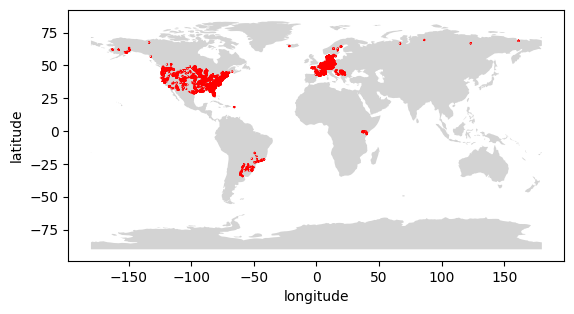

In [26]:
filtered_CN_SRP_2['n_samples'] = filtered_CN_SRP_2['n_samples'].astype(float)
worldmap = gpd.read_file(geodatasets.get_path('naturalearth.land'))
#worldmap = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
ax = worldmap.plot(color="lightgrey")
filtered_CN_SRP_2.boundary.plot(ax=ax, color = 'red')
#plt.title('Catchments DOC_TOC:DIN:SRP')
plt.xlabel("longitude")
plt.ylabel("latitude")
#plt.savefig('../../figures/availability_CNP_basins/worldmap_DOC-TOC_DIN_SRP_basins.png')
plt.show()


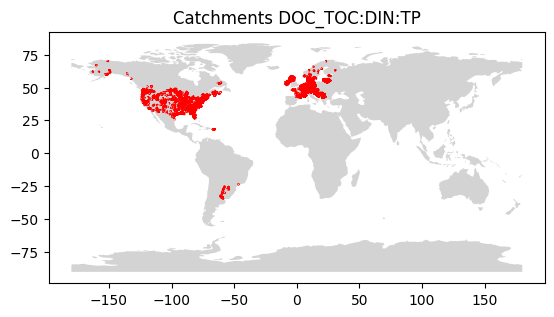

In [27]:
ax = worldmap.plot(color="lightgrey")
filtered_CN_TP_2.boundary.plot(ax=ax, color = 'red')
plt.title('Catchments DOC_TOC:DIN:TP')
#plt.savefig('../../figures/availability_CNP_basins/worldmap_DOC-TOC_DIN_TP_basins.png')
plt.show()
